# INITIALIZATION

In [1]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from config import BCI2A_PATH, MI_DATA_PATH, LOW_FREQ, HIGH_FREQ, SAMPLING_RATE, BCI_MAPPING
from autoreject import AutoReject
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


LOW_FREQ = 8.
HIGH_FREQ = 30.
SAMPLING_RATE = 250

In [2]:
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1', 'Pz', 'P2',
    'POz',
    'EOG-left', 'EOG-central', 'EOG-right'
]

In [3]:
def load_data(path, channels = ['C3', 'C4', 'Cz'], format = '.gdf', sampling_rate = SAMPLING_RATE, low_freq = LOW_FREQ, high_freq = HIGH_FREQ, mapping = None, transform = None):
    parent_dir = os.path.dirname(path)
    raw_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.endswith(format)]
    print(f"Found {len(raw_files)} raw data files in {path}.")
    raw_data = []
    for file in raw_files:
        raw = mne.io.read_raw_gdf(file, preload=True)

        if raw.info['sfreq'] != sampling_rate:
            raw.resample(sampling_rate)

        if transform is not None:
            raw.rename_channels(lambda x: transform(x))        

        if mapping is not None:
            raw.rename_channels(mapping)
    
        raw.set_channel_types({
            'EOG-left': 'eog',
            'EOG-central': 'eog',
            'EOG-right': 'eog'
        })

        raw.set_montage('standard_1020')

        if channels is not None:
            raw.pick_channels(channels)

        raw.filter(low_freq, high_freq)

        raw_data.append(raw)
    return raw_data    

In [4]:
def bci2a_transform(channel_name):
    return channel_name.replace('EEG-', '')

In [5]:
training_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4', 
    # 'EOG-left', 'EOG-central', 'EOG-right'],
    low_freq=LOW_FREQ, 
    high_freq=HIGH_FREQ, 
    format = 'T.gdf')


evaluation_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4', 
    # 'EOG-left', 'EOG-central', 'EOG-right'],
    low_freq=LOW_FREQ,
    high_freq=HIGH_FREQ,
    format = 'E.gdf')

Found 9 raw data files in ./data/BCI-2A/.
Extracting GDF parameters from ./data/BCI-2A\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A08E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 687791  =      0.000 ...  2751.164 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A09E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 675097  =      0.000 ...  2700.388 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



In [6]:
print(f"Loaded Training BCI2A data: {len(training_bci)} files")
print(f"Loaded Evaluation BCI2A data: {len(evaluation_bci)} files")

Loaded Training BCI2A data: 9 files
Loaded Evaluation BCI2A data: 9 files


In [7]:
event, event_id = mne.events_from_annotations(training_bci[0])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Events found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Event : (603, 3)


In [8]:
event, event_id = mne.events_from_annotations(evaluation_bci[1])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('783')]
Events found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('783'): 7}
Event : (593, 3)


# PREPROCESSING 

In [9]:
BCI_Label_Mappings = {
    np.str_("769"): 0,  # Left Hand
    np.str_("770"): 1,  # Right Hand
}

In [10]:
from mne.preprocessing import ICA

def remove_eog_regression(raw):
    eog_data = raw.copy().pick_types(eog=True).get_data()
    eeg_data = raw.copy().pick_types(eeg=True).get_data()

    # Simple regression coefficient
    alpha = np.dot(eeg_data, eog_data.T) @ np.linalg.pinv(np.dot(eog_data, eog_data.T))

    eeg_clean = eeg_data - alpha @ eog_data

    raw_clean = raw.copy()
    raw_clean._data[:eeg_data.shape[0], :] = eeg_clean

    return raw_clean


def run_ica(raw, n_components=20):
    ica = ICA(n_components=n_components, random_state=42, max_iter="auto")
    ica.fit(raw)

    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices

    raw_clean = raw.copy()
    ica.apply(raw_clean)
    return raw_clean


def create_epochs(raw, event_id):
    events, _ = mne.events_from_annotations(raw, event_id=event_id)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0.5,
        tmax=4,
        baseline=None,
        preload=True
    )
    return epochs

from scipy.signal import welch

def compute_psd(X, fs=250):
    psd_features = []
    for epoch in X:
        ch_psd = []
        for ch in epoch:
            f, Pxx = welch(ch, fs=fs, nperseg=fs*2)
            ch_psd.append(Pxx)
        psd_features.append(ch_psd)

    return np.array(psd_features)

def preprocess_raw(raw, event_id):
    raw = run_ica(raw, 6)
    # raw = remove_eog_regression(raw)
    epochs = create_epochs(raw, event_id)
    # X = compute_psd(epochs.get_data(), fs=SAMPLING_RATE)
    X, y = epochs.get_data(), epochs.events[:, -1]
    return X, y

In [11]:
from mne.preprocessing import ICA

def run_ica(raw, n_components=20):
    ica = ICA(n_components=n_components, random_state=42, max_iter="auto")
    ica.fit(raw)

    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices

    raw_clean = raw.copy()
    ica.apply(raw_clean)
    return raw_clean

def create_epochs(raw, event_id):
    events, _ = mne.events_from_annotations(raw, event_id=event_id)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0.5,
        tmax=4.5,
        baseline=None,
        preload=True
    )
    return epochs

bands = [(8,12), (12,20), (20,30)]
def multi_band_filter(raw, bands):
    band_data = []
    for l, h in bands:
        filtered = raw.copy().filter(l, h, verbose=False)
        band_data.append(filtered.get_data())  # (C, T)
    
    return np.concatenate(band_data, axis=1)  # (C * num_bands, T)


def preprocess_raw(raw, event_id, bands=None):
    raw_clean = run_ica(raw, n_components=21)
    epochs = create_epochs(raw_clean, event_id)
    X, y = epochs.get_data(), epochs.events[:, -1]
    # X, y = multi_band_filter(epochs, bands), epochs.events[:, -1]
    return X, y


In [12]:
from sklearn.model_selection import train_test_split
X_all, y_all = [], []

for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, BCI_Label_Mappings)
    X_all.append(X_raw)
    y_all.append(y_raw)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 21 components
Fitting ICA took 15.3s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower tra

In [13]:
mean = X_train.mean(axis=(0,2), keepdims=True)
std  = X_train.std(axis=(0,2), keepdims=True)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std

In [14]:
X_train.shape, y_train.shape

((1036, 25, 1001), (1036,))

In [15]:
# Checking Balance in Training Data
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")


Class Distribution in Training Data:
Class 0: 518 samples
Class 1: 518 samples


In [16]:
X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
X_val   = np.transpose(X_val, (0, 2, 1))

In [17]:
X_train.shape, y_train.shape

((1036, 1001, 25), (1036,))

# EEGNET MODEL

In [ ]:
# import math
# import torch.nn.functional as F
    
# class EEGNetBlock(nn.Module):
#     def __init__(self, n_channels):
#         super().__init__()

#         F1 = 64   # temporal filters
#         D = 2     # depth multiplier
#         F2 = F1 * D

#         # 1. Temporal conv (frequency extraction)
#         self.temporal = nn.Sequential(
#             nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
#             nn.BatchNorm2d(F1),
#         )

#         # 2. Depthwise spatial conv
#         self.spatial = nn.Sequential(
#             nn.Conv2d(F1, F2, (n_channels, 1), groups=F1, bias=False),
#             nn.BatchNorm2d(F2),
#             nn.ELU(),
#         )

#         # 3. Separable conv (refinement)
#         self.separable = nn.Sequential(
#             nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
#             nn.Conv2d(F2, F2, 1, bias=False),
#             nn.BatchNorm2d(F2),
#             nn.ELU(),
#             nn.Dropout(0.25),
#         )

#         self.pool = nn.AvgPool2d((1, 2))

#     def forward(self, x):
#         # x: (B, C, T)
#         x = x.unsqueeze(1)  # (B, 1, C, T)

#         x = self.temporal(x)
#         x = self.spatial(x)
#         x = self.separable(x)
#         x = self.pool(x)

#         x = x.squeeze(2)  # (B, F, T)
#         return x

# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_len=5000):
#         super().__init__()
#         pe = torch.zeros(max_len, d_model)
#         pos = torch.arange(0, max_len).unsqueeze(1)
#         div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

#         pe[:, 0::2] = torch.sin(pos * div)
#         pe[:, 1::2] = torch.cos(pos * div)

#         self.pe = pe.unsqueeze(0)

#     def forward(self, x):
#         return x + self.pe[:, :x.size(1)].to(x.device)


# class ResidualBlock(nn.Module):
#     def __init__(self, channels):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv1d(channels, channels, kernel_size=5, padding=2),
#             nn.BatchNorm1d(channels),
#             nn.ReLU(),
#             nn.Conv1d(channels, channels, kernel_size=5, padding=2),
#             nn.BatchNorm1d(channels)
#         )

#     def forward(self, x):
#         return F.relu(x + self.block(x))

# class EEGModel(nn.Module):
#     def __init__(self, n_channels, n_classes):
#         super().__init__()

#         self.pos_enc = PositionalEncoding(128)
#         self.eegnet = EEGNetBlock(n_channels)


#         # Transformer
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=128,
#             nhead=4,
#             dim_feedforward=256,
#             dropout=0.3,
#             batch_first=True
#         )

#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

#         self.fc = nn.Sequential(
#             nn.Linear(128, 128),  
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, n_classes)
#         )

#         self.attn_pool = nn.Linear(128, 1)
#         self.norm = nn.LayerNorm(128)

#     def forward(self, x):
#         x = x.permute(0, 2, 1)  

#         x = self.eegnet(x)      

#         x = x.permute(0, 2, 1)  

#         x = self.pos_enc(x)     
#         x = self.norm(x)
#         x = self.transformer(x)

#         weights = torch.softmax(self.attn_pool(x), dim=1)
#         x = (x * weights).sum(dim=1)

#         return self.fc(x)

# CNN + TRANSFORMER MODEL

In [ ]:
# import math
# import torch.nn.functional as F
    
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_len=5000):
#         super().__init__()
#         pe = torch.zeros(max_len, d_model)
#         pos = torch.arange(0, max_len).unsqueeze(1)
#         div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

#         pe[:, 0::2] = torch.sin(pos * div)
#         pe[:, 1::2] = torch.cos(pos * div)

#         self.pe = pe.unsqueeze(0)

#     def forward(self, x):
#         return x + self.pe[:, :x.size(1)].to(x.device)


# class ResidualBlock(nn.Module):
#     def __init__(self, channels):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv1d(channels, channels, kernel_size=5, padding=2),
#             nn.BatchNorm1d(channels),
#             nn.ReLU(),
#             nn.Conv1d(channels, channels, kernel_size=5, padding=2),
#             nn.BatchNorm1d(channels)
#         )

#     def forward(self, x):
#         return F.relu(x + self.block(x))

# class EEGModel(nn.Module):
#     def __init__(self, n_channels, n_classes):
#         super().__init__()


#         self.spatial = nn.Conv1d(n_channels, 256, kernel_size=1)

#         self.pos_enc = PositionalEncoding(256)

#         # Temporal CNN
#         self.cnn = nn.Sequential(
#             ResidualBlock(256),
#             nn.MaxPool1d(2),
#             ResidualBlock(256),
#             nn.MaxPool1d(2),
#         )

#         # Transformer
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=256,
#             nhead=4,
#             dim_feedforward=256,
#             dropout=0.3,
#             batch_first=True
#         )

#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

#         self.fc = nn.Sequential(
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, n_classes)
#         )

#     def forward(self, x):
#         x = x.permute(0, 2, 1)   # (N, C, T)

#         x = self.spatial(x)
#         x = self.cnn(x)

#         x = x.permute(0, 2, 1)   # (N, T, F)
#         x = self.pos_enc(x)
#         x = self.transformer(x)

#         x = x.mean(dim=1) 
#         return self.fc(x)

# Modified Model

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ---------------------------
# Positional Encoding
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


# ---------------------------
# Multi-scale Residual Block
# ---------------------------
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels=None):
        super().__init__()

        if out_channels is None:
            out_channels = in_channels

        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)

        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        out = self.conv3(x) + self.conv5(x) + self.conv7(x)
        out = self.bn(out)
        return F.leaky_relu(x + out)


# ---------------------------
# EEG Model
# ---------------------------
class EEGModel(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        # Spatial Projection
        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, 256, kernel_size=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU()
        )

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            MultiScaleBlock(256),
            nn.MaxPool1d(2),

            MultiScaleBlock(256),
            nn.MaxPool1d(2),

            MultiScaleBlock(256),
        )

        # Positional Encoding
        self.pos_enc = PositionalEncoding(256)

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=4,
            dim_feedforward=512,   # increased
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Classification Head (Adaptive)
        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        # (N, T, C) -> (N, C, T)
        x = x.permute(0, 2, 1)

        x = self.spatial(x)
        x = self.cnn(x)

        # (N, C, T) -> (N, T, C)
        x = x.permute(0, 2, 1)

        # Add positional encoding
        x = self.pos_enc(x)

        x = self.transformer(x)

        # Global Average Pooling (robust)
        x = x.mean(dim=1)

        return self.fc(x)

In [19]:
model = EEGModel(n_channels=X_train.shape[2], n_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

In [20]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    preds, labels = [], []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc

In [21]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [22]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
from tqdm import tqdm
import torch

def augment(x):
    # x: (B, T, C)

    # Gaussian noise
    x = x + 0.01 * torch.randn_like(x)

    # Time shift
    shift = np.random.randint(-20, 20)
    x = torch.roll(x, shifts=shift, dims=1)

    # Channel dropout
    if np.random.rand() < 0.3:
        mask = torch.rand(x.shape[2], device=x.device) > 0.1
        x = x * mask

    return x

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for X_batch, y_batch in loop:
            X_batch = augment(X_batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss) 
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [24]:
def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    print("Final Accuracy:", accuracy_score(labels, preds))
    print(classification_report(labels, preds))

In [25]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()


Epoch 1/80
Train Loss: 1.3318
Val Loss: 1.3056 | Val Acc: 0.4885



Epoch 2/80
Train Loss: 1.2196
Val Loss: 1.2939 | Val Acc: 0.4500



Epoch 3/80
Train Loss: 1.1360
Val Loss: 1.1826 | Val Acc: 0.5885



Epoch 4/80
Train Loss: 0.9708
Val Loss: 1.1185 | Val Acc: 0.6038



Epoch 5/80
Train Loss: 0.8994
Val Loss: 0.8755 | Val Acc: 0.7654


...


Epoch 76/80
Train Loss: 0.3788
Val Loss: 0.2746 | Val Acc: 0.8423



Epoch 77/80
Train Loss: 0.1400
Val Loss: 0.2716 | Val Acc: 0.8346



Epoch 78/80
Train Loss: 0.0792
Val Loss: 0.2586 | Val Acc: 0.8385



Epoch 79/80
Train Loss: 0.1060
Val Loss: 0.2524 | Val Acc: 0.8385



Epoch 80/80
Train Loss: 0.0988
Val Loss: 0.2576 | Val Acc: 0.8385


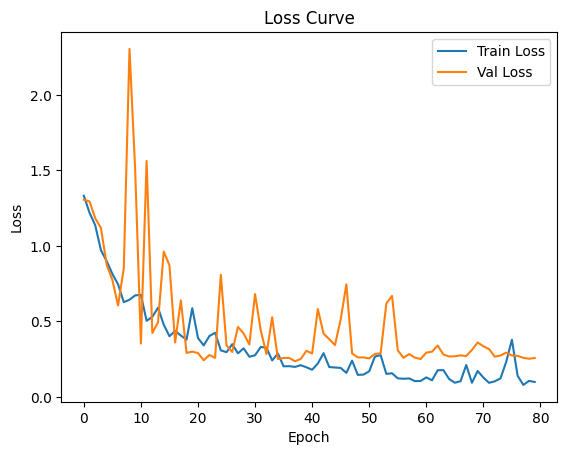

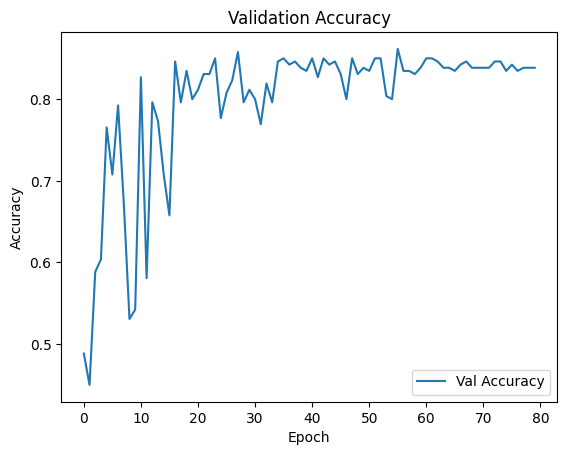

Final Accuracy: 0.8384615384615385
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       130
           1       0.87      0.79      0.83       130

    accuracy                           0.84       260
   macro avg       0.84      0.84      0.84       260
weighted avg       0.84      0.84      0.84       260



In [26]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler=scheduler,
    epochs=80,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

In [27]:
torch.save(model.state_dict(), "./output/eeg_model.pth")

# TRAINING PER SUBJECT 

In [32]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
BATCH_SIZE = 256
EPOCHS = 20

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 21 components
Fitting ICA took 15.2s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower tra


Epoch 1/20
Train Loss: 1.5019
Val Loss: 1.3096 | Val Acc: 0.7586



Epoch 2/20
Train Loss: 1.3272
Val Loss: 1.3410 | Val Acc: 0.5172



Epoch 3/20
Train Loss: 1.2220
Val Loss: 1.3642 | Val Acc: 0.4828



Epoch 4/20
Train Loss: 1.1494
Val Loss: 1.3747 | Val Acc: 0.6207


...


Epoch 16/20
Train Loss: 0.6110
Val Loss: 1.2422 | Val Acc: 0.5517



Epoch 17/20
Train Loss: 0.5797
Val Loss: 1.2374 | Val Acc: 0.5172



Epoch 18/20
Train Loss: 0.5729
Val Loss: 1.2327 | Val Acc: 0.5172



Epoch 19/20
Train Loss: 0.5591
Val Loss: 1.2251 | Val Acc: 0.5172



Epoch 20/20
Train Loss: 0.5653
Val Loss: 1.2164 | Val Acc: 0.5172


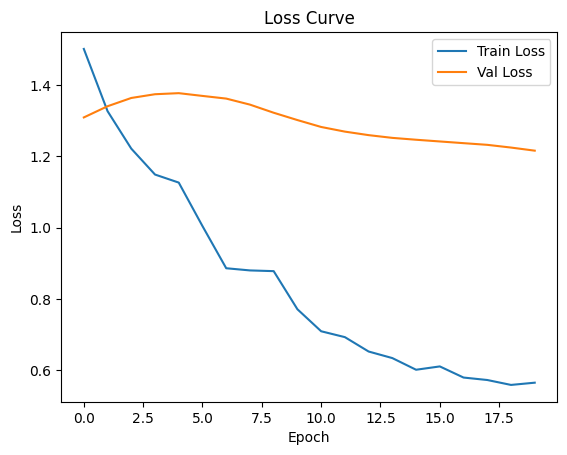

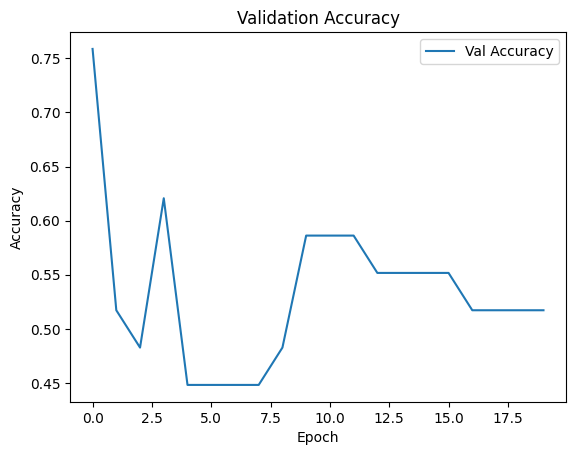

Final Accuracy: 0.5172413793103449
              precision    recall  f1-score   support

           0       1.00      0.07      0.12        15
           1       0.52      1.00      0.68        14
           2       0.00      0.00      0.00         0

    accuracy                           0.52        29
   macro avg       0.51      0.36      0.27        29
weighted avg       0.77      0.52      0.39        29

Fitting ICA to data using 22 channels (please be patient, this may take a while)


d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Selecting by number: 21 components
Fitting ICA took 10.7s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband ed


Epoch 1/20
Train Loss: 1.4765
Val Loss: 1.4141 | Val Acc: 0.0000



Epoch 2/20
Train Loss: 1.2843
Val Loss: 1.4145 | Val Acc: 0.0000


...


Epoch 16/20
Train Loss: 0.5669
Val Loss: 1.2629 | Val Acc: 0.5172



Epoch 17/20
Train Loss: 0.5458
Val Loss: 1.2670 | Val Acc: 0.5172



Epoch 18/20
Train Loss: 0.5598
Val Loss: 1.2636 | Val Acc: 0.5862



Epoch 19/20
Train Loss: 0.5349
Val Loss: 1.2603 | Val Acc: 0.5862



Epoch 20/20
Train Loss: 0.5025
Val Loss: 1.2545 | Val Acc: 0.5862


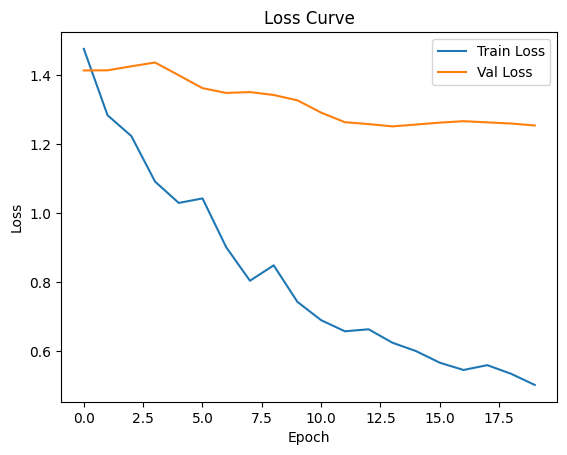

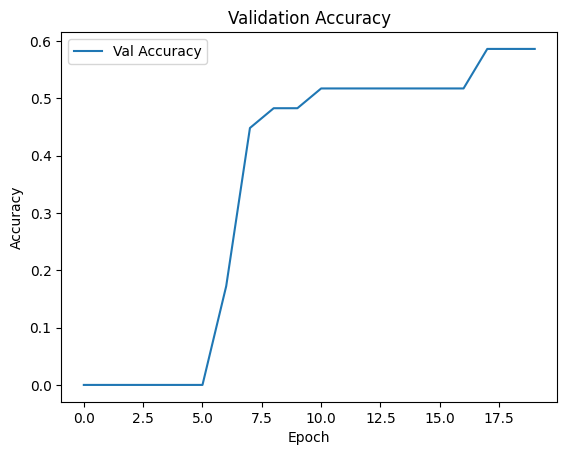

Final Accuracy: 0.5862068965517241
              precision    recall  f1-score   support

           0       0.80      0.27      0.40        15
           1       0.54      0.93      0.68        14

    accuracy                           0.59        29
   macro avg       0.67      0.60      0.54        29
weighted avg       0.68      0.59      0.54        29

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 21 components
Fitting ICA took 15.8s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cuto


Epoch 1/20
Train Loss: 1.3088
Val Loss: 1.2694 | Val Acc: 0.5172



Epoch 2/20
Train Loss: 1.0222
Val Loss: 1.2503 | Val Acc: 0.5172



Epoch 3/20
Train Loss: 0.7937
Val Loss: 1.2271 | Val Acc: 0.5172



Epoch 4/20
Train Loss: 0.6868
Val Loss: 1.1934 | Val Acc: 0.5172


...


Epoch 16/20
Train Loss: 0.2697
Val Loss: 0.8325 | Val Acc: 0.8276



Epoch 17/20
Train Loss: 0.3066
Val Loss: 0.8035 | Val Acc: 0.8276



Epoch 18/20
Train Loss: 0.2455
Val Loss: 0.7715 | Val Acc: 0.8276



Epoch 19/20
Train Loss: 0.2694
Val Loss: 0.7338 | Val Acc: 0.8276



Epoch 20/20
Train Loss: 0.2929
Val Loss: 0.6848 | Val Acc: 0.8966


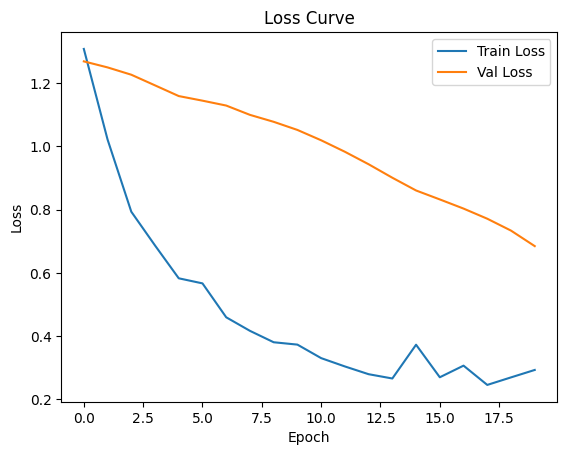

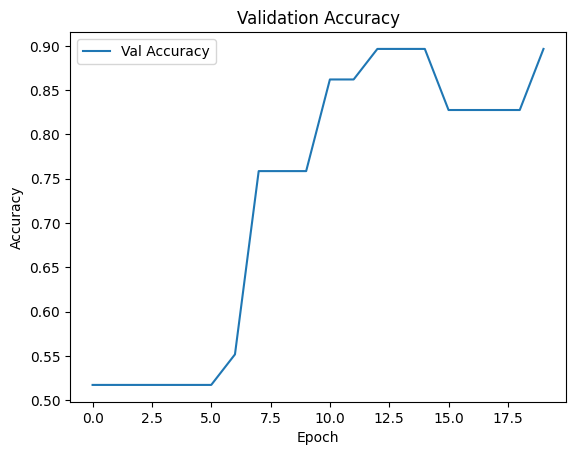

Final Accuracy: 0.896551724137931
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.87      0.93      0.90        14

    accuracy                           0.90        29
   macro avg       0.90      0.90      0.90        29
weighted avg       0.90      0.90      0.90        29

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 21 components
Fitting ICA took 12.5s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutof


Epoch 1/20
Train Loss: 1.5578
Val Loss: 1.4409 | Val Acc: 0.0000



Epoch 2/20
Train Loss: 1.4077
Val Loss: 1.4227 | Val Acc: 0.0000



Epoch 3/20
Train Loss: 1.3271
Val Loss: 1.3516 | Val Acc: 0.0000



Epoch 4/20
Train Loss: 1.1673
Val Loss: 1.2977 | Val Acc: 0.2759


...


Epoch 16/20
Train Loss: 0.7109
Val Loss: 1.3827 | Val Acc: 0.1034



Epoch 17/20
Train Loss: 0.6481
Val Loss: 1.3811 | Val Acc: 0.0345



Epoch 18/20
Train Loss: 0.7796
Val Loss: 1.3787 | Val Acc: 0.0690



Epoch 19/20
Train Loss: 0.6307
Val Loss: 1.3749 | Val Acc: 0.1034



Epoch 20/20
Train Loss: 0.6944
Val Loss: 1.3729 | Val Acc: 0.1379


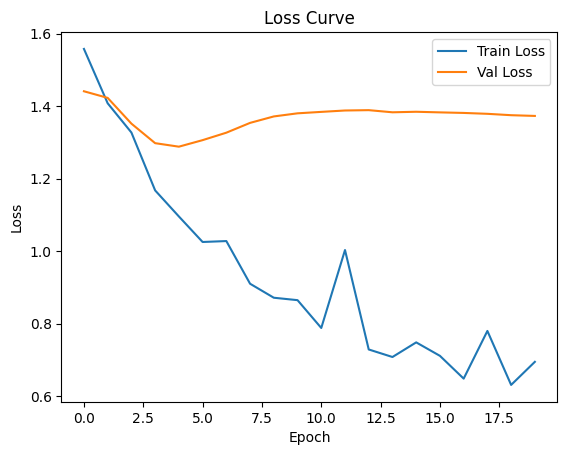

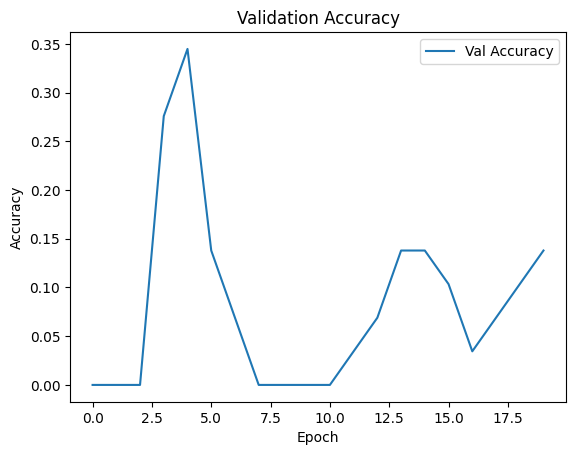

Final Accuracy: 0.13793103448275862
              precision    recall  f1-score   support

           0       0.67      0.27      0.38        15
           1       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         0

    accuracy                           0.14        29
   macro avg       0.22      0.09      0.13        29
weighted avg       0.34      0.14      0.20        29

Fitting ICA to data using 22 channels (please be patient, this may take a while)


d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib

Selecting by number: 21 components
Fitting ICA took 10.1s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband ed


Epoch 1/20
Train Loss: 1.5151
Val Loss: 1.4925 | Val Acc: 0.0000



Epoch 2/20
Train Loss: 1.3442
Val Loss: 1.4561 | Val Acc: 0.0000


...


Epoch 16/20
Train Loss: 0.6217
Val Loss: 1.2779 | Val Acc: 0.4138



Epoch 17/20
Train Loss: 0.5643
Val Loss: 1.2567 | Val Acc: 0.4138



Epoch 18/20
Train Loss: 0.5927
Val Loss: 1.2360 | Val Acc: 0.4828



Epoch 19/20
Train Loss: 0.6068
Val Loss: 1.2187 | Val Acc: 0.4828



Epoch 20/20
Train Loss: 0.5290
Val Loss: 1.1984 | Val Acc: 0.5172


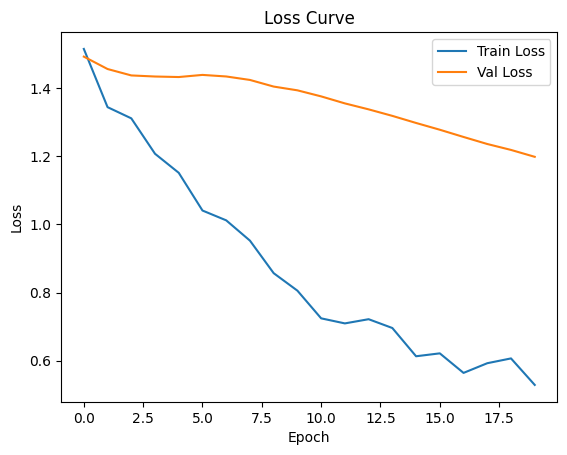

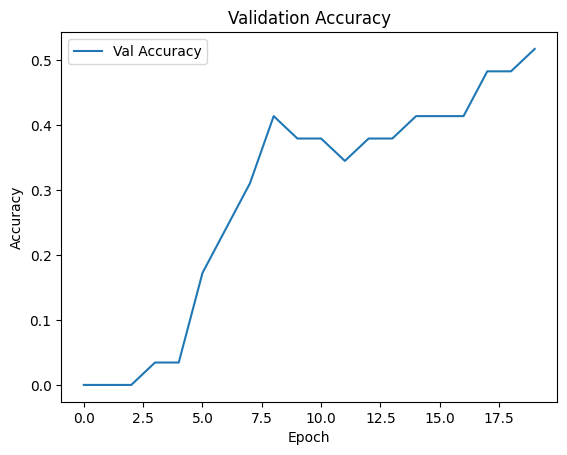

Final Accuracy: 0.5172413793103449
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        15
           1       1.00      0.29      0.44        14
           2       0.00      0.00      0.00         0

    accuracy                           0.52        29
   macro avg       0.62      0.34      0.41        29
weighted avg       0.92      0.52      0.62        29

Fitting ICA to data using 22 channels (please be patient, this may take a while)


d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Selecting by number: 21 components
Fitting ICA took 12.0s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband ed


Epoch 1/20
Train Loss: 1.5029
Val Loss: 1.5330 | Val Acc: 0.0000



Epoch 2/20
Train Loss: 1.3911
Val Loss: 1.4955 | Val Acc: 0.0000


...


Epoch 16/20
Train Loss: 0.7483
Val Loss: 1.3111 | Val Acc: 0.4483



Epoch 17/20
Train Loss: 0.7829
Val Loss: 1.3002 | Val Acc: 0.4483



Epoch 18/20
Train Loss: 0.6774
Val Loss: 1.2904 | Val Acc: 0.5172



Epoch 19/20
Train Loss: 0.6654
Val Loss: 1.2817 | Val Acc: 0.5517



Epoch 20/20
Train Loss: 0.6322
Val Loss: 1.2731 | Val Acc: 0.5862


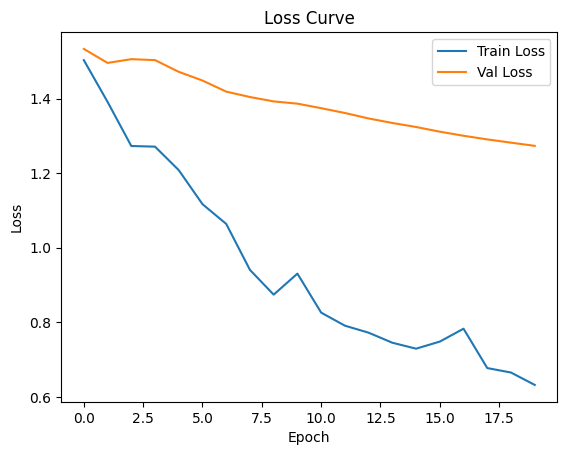

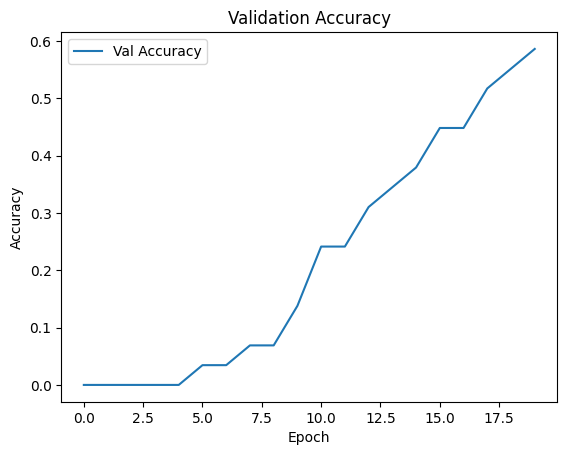

Final Accuracy: 0.5862068965517241
              precision    recall  f1-score   support

           0       0.64      0.60      0.62        15
           1       0.73      0.57      0.64        14
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.59        29
   macro avg       0.34      0.29      0.32        29
weighted avg       0.68      0.59      0.63        29



d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\EEG_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
num = 5
for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, event_id=BCI_Label_Mappings)

    X = np.array(X_raw)
    y = np.array(y_raw)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mean = X_train.mean(axis=(0,2), keepdims=True)
    std  = X_train.std(axis=(0,2), keepdims=True)

    X_train = (X_train - mean) / std
    X_val   = (X_val - mean) / std

    X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
    X_val   = np.transpose(X_val, (0, 2, 1))

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model2 = EEGModel(n_channels=X_train.shape[2], n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model2.parameters(), lr=1e-4)

    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',
    #     factor=0.5,
    #     patience=5
    # )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,     
        eta_min=1e-5 
    )

    history = train(
        model2,
        train_loader,
        val_loader,
        optimizer,
        criterion,        
        scheduler = scheduler,
        epochs=EPOCHS,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    plot_history(history)
    final_evaluation(model2, val_loader, device="cuda" if torch.cuda.is_available() else "cpu")

    if num == 0:
        break
    num -= 1

    